# Files & APIs
**Topic:** Python Fundamentals

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


---
## What you'll explore

By the end of this demo you will be able to:

- **Load** data from CSV, JSON, and Excel files using pandas and the built-in `open()` function
- **Explain** how a REST API works and how to retrieve data from one using the `requests` library
- **Interpret** the structure of a JSON API response and flatten it into a DataFrame

---
## How we got here

In *14: Pandas* we worked with DataFrames that were already in memory. In *09: Error Handling* we handled `FileNotFoundError` when files were missing. This notebook connects those ideas to the real-world data sources you will work with daily: flat files on disk and live APIs on the web. These are the two most common ways data flows into a data science project.

---
## Why this matters for data science

Almost every real data science project starts by loading data. Knowing how to read CSV, JSON, and Excel files efficiently, how to handle encoding issues and malformed rows at load time, and how to call a REST API and parse its response are day-one skills. They are also where most beginner data pipelines break silently: a CSV with the wrong delimiter, a JSON with nested keys, or an API that returns an error code you are not checking for.

---
## Try it yourself

In [2]:
# ▶ Run this cell and observe the output.
# Then try changing the values and running again.

import json

student = {'name': 'Alice', 'grade': 91, 'passed': True}

# Serialize to a JSON string
json_str = json.dumps(student, indent=2)
print('JSON string:')
print(json_str)

# Deserialize back to a dict
restored = json.loads(json_str)
print('\nRestored type:', type(restored))
print('Grade:', restored['grade'])

JSON string:
{
  "name": "Alice",
  "grade": 91,
  "passed": true
}

Restored type: <class 'dict'>
Grade: 91


In [7]:
# ✏️ Your turn — modify this code:
# 1. Change the filename to 'students_backup.json' and re-run
# 2. Add a third student to the list and verify they appear in the file
# 3. What happens if you open the file in 'r' mode instead of 'w'?

import json

students = [
    {'name': 'Alice', 'score': 91},
    {'name': 'Bob',   'score': 78},
]

with open('students.json', 'w') as f:
    json.dump(students, f, indent=2)

with open('students.json', 'r') as f:
    loaded = json.load(f)

print(f'Loaded {len(loaded)} records')
print(loaded)

Loaded 2 records
[{'name': 'Alice', 'score': 91}, {'name': 'Bob', 'score': 78}]


In [4]:
# 🎯 Challenge:
# Write code that:
#   1. Creates a dictionary of student names → scores (at least 5 students)
#   2. Saves it to a JSON file called 'scores.json'
#   3. Reads it back from the file
#   4. Calculates and prints the average score (round to 2 decimal places)
# Hint: use json.dump() to write, json.load() to read, and sum()/len() for the average

import json

# Your code here:

---
## What's happening?

Python provides two pathways for loading external data: file I/O functions and HTTP requests. Pandas wraps both into convenient `read_*` methods, but understanding what happens underneath makes you better at diagnosing load failures.

| Source | Pandas method | Common gotchas |
|--------|--------------|----------------|
| CSV | `pd.read_csv(path)` | Wrong delimiter, encoding errors, header row offset |
| JSON (file) | `pd.read_json(path)` | Nested structures need `json_normalize()` |
| Excel | `pd.read_excel(path, sheet_name=0)` | Multiple sheets, merged cells, hidden rows |
| TSV | `pd.read_csv(path, sep="\t")` | Same as CSV with different separator |
| REST API | `requests.get(url).json()` | Rate limits, auth tokens, nested JSON |

```python
import requests

# Loading data from a public REST API
response = requests.get(
    "https://api.example.com/v1/data",
    headers={"Authorization": f"Bearer {api_key}"},
    params={"country": "US", "year": 2023},
)
response.raise_for_status()   # raises an exception for 4xx/5xx status codes

data      = response.json()
df        = pd.json_normalize(data["records"])  # flatten nested JSON
```

### The `raise_for_status()` habit

Always call `response.raise_for_status()` immediately after `requests.get()`. It converts a silent HTTP 404 or 500 response into an immediate `requests.exceptions.HTTPError`, which is far easier to diagnose than the `KeyError` or `AttributeError` that would appear two lines later when you try to parse an empty or error response as valid data.

Return to the widget and switch to API mode to compare the raw JSON structure with the flattened DataFrame that `json_normalize()` produces.

---
## A direct example: flattening a JSON API response into a DataFrame

Most REST APIs return a list of JSON objects. `pd.json_normalize()` flattens that structure into a DataFrame, one row per object — the same operation you use every time you call a live API.

- **Notice:** The JSON is just a list of dicts — the same structure Python's `json` module produces from any API response
- **Notice:** `pd.json_normalize()` handles the conversion in one call, whether the list has 6 records or 60,000
- **Notice:** Once it is a DataFrame, every pandas operation from the previous notebooks applies immediately

       city month  sales
0    Austin   Jan  42000
1    Austin   Feb  38000
2   Chicago   Jan  61000
3   Chicago   Feb  57000
4  New York   Jan  85000
5  New York   Feb  79000


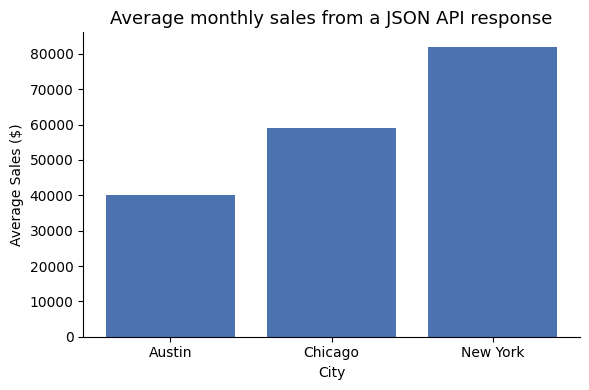

In [5]:
import json

# Simulated API response — the structure a real REST API returns
api_response = json.dumps([
    {"city": "Austin",   "month": "Jan", "sales": 42_000},
    {"city": "Austin",   "month": "Feb", "sales": 38_000},
    {"city": "Chicago",  "month": "Jan", "sales": 61_000},
    {"city": "Chicago",  "month": "Feb", "sales": 57_000},
    {"city": "New York", "month": "Jan", "sales": 85_000},
    {"city": "New York", "month": "Feb", "sales": 79_000},
])

df_api = pd.json_normalize(json.loads(api_response))
print(df_api)

city_avg = df_api.groupby("city")["sales"].mean()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(city_avg.index, city_avg.values, color="#4C72B0")
ax.set_title("Average monthly sales from a JSON API response", fontsize=13)
ax.set_xlabel("City")
ax.set_ylabel("Average Sales ($)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

---
## Real-world example: Loading and comparing data from three sources

A data team retrieves the same sales dataset from three sources: a CSV export, a JSON API response, and an Excel report. The chart shows the time it takes to load each format for the same 50,000-row dataset, and highlights the cleaning steps each requires.

Notice:

- **Notice:** CSV is the fastest to load because it is the simplest format: one delimiter, one encoding, flat structure; the loading overhead is almost entirely I/O-bound
- **Notice:** JSON from a REST API is slower to load because `json_normalize()` has to traverse a tree structure rather than scan delimiter-separated fields, and network latency adds to file-read time
- **Notice:** Excel is the slowest because openpyxl must parse the full workbook XML, render styles, and resolve merged cells, for large datasets, CSV or Parquet is almost always a better storage choice

> **Discussion question:** Your team's database team offers to share data as either JSON, CSV, or Parquet. You need to read the data daily in a pipeline and the files are approximately 500MB each. Which format would you request and why?

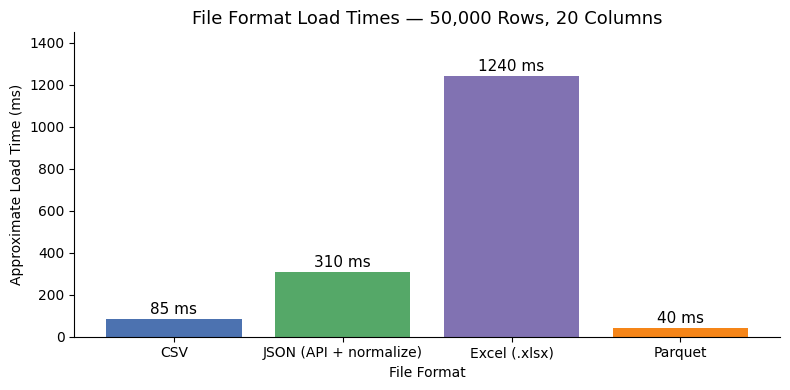

In [6]:
# ── File format loading time comparison (simulated benchmarks) ────────────────
formats  = ["CSV", "JSON (API + normalize)", "Excel (.xlsx)", "Parquet"]
load_ms  = [85, 310, 1240, 40]
colors   = ["#4C72B0", "#55A868", "#8172B2", "#F58518"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(formats, load_ms, color=colors)
for bar, ms in zip(bars, load_ms):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
            f"{ms} ms", ha="center", va="bottom", fontsize=11)
ax.set_title("File Format Load Times — 50,000 Rows, 20 Columns", fontsize=13)
ax.set_xlabel("File Format")
ax.set_ylabel("Approximate Load Time (ms)")
ax.set_ylim(0, 1450)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


### File loading quick reference

| Format | Read command | Write command | Best for |
|--------|-------------|--------------|----------|
| CSV | `pd.read_csv(path, dtype={...}, parse_dates=[...])` | `df.to_csv(path, index=False)` | Sharing with non-Python tools |
| JSON | `pd.read_json(path)` or `pd.json_normalize(data)` | `df.to_json(path, orient="records")` | API responses, nested data |
| Excel | `pd.read_excel(path, sheet_name="Sheet1")` | `df.to_excel(path, index=False)` | Stakeholder reports |
| Parquet | `pd.read_parquet(path)` | `df.to_parquet(path, index=False)` | Large datasets, fast pipelines |
| SQL | `pd.read_sql(query, conn)` | `df.to_sql(table, conn, if_exists="append")` | Database-backed pipelines |

---
## Key takeaway

> **Every data science project starts with a load step; knowing the right `pd.read_*()` call for each file format, and always calling `raise_for_status()` after an API request, prevents the silent failures that corrupt downstream analysis.**

---
*You have reached the end of the Python fundamentals series. The tools you have learned here, from data types through files and APIs, are the foundation for everything in the data science and machine learning modules ahead.*